## Carregar proteínas para testes

Carregaremos 100 sequências proteicas da base [UniProt](https://www.uniprot.org/), combinando 20 pares de proteínas para testes aleatórios.

In [1]:
from functions import fetch_proteins, sample_pairs


sequences = fetch_proteins(size=100)
pairs = sample_pairs(sequences, n_pairs=20)
print(f"{len(sequences)} downloaded sequences")
print(f"{len(pairs)} generated pairs")

100 downloaded sequences
20 generated pairs


## Prova de corretude

### Caso 1 — Sequências curtas com mutações leves

Deve-se esperar:
* Um gap pequeno para alinhar corretamente;
* Muitos matches consecutivos;
* Penalização mínima.

Alinhamento esperado:

```txt
M K T L L I L A V
M K T - L I L A V
```

In [2]:
from functions import run_alignment


seq1 = "MKTLLILAV"
seq2 = "MKTLILAV"

run_alignment(seq1, seq2)

Alinhando as seguintes proteínas:
MKTLLILAV
MKTLILAV

Best alignment:
MKTLLILAV
MKT-LILAV

Score: 30.0
Tempo de execução: 2.78 s
Memória consumida: 0.02 MiB


([24.0,
  30.0,
  30.0,
  30.0,
  30.0,
  30.0,
  30.0,
  30.0,
  30.0,
  30.0,
  30.0,
  30.0,
  30.0,
  30.0,
  30.0,
  30.0,
  30.0,
  30.0,
  30.0,
  30.0,
  30.0,
  30.0,
  30.0,
  30.0,
  30.0,
  30.0,
  30.0,
  30.0,
  30.0,
  30.0,
  30.0,
  30.0,
  30.0,
  30.0,
  30.0,
  30.0,
  30.0,
  30.0,
  30.0,
  30.0,
  30.0,
  30.0,
  30.0,
  30.0,
  30.0,
  30.0,
  30.0,
  30.0,
  30.0,
  30.0,
  30.0,
  30.0,
  30.0,
  30.0,
  30.0,
  30.0,
  30.0,
  30.0,
  30.0,
  30.0,
  30.0,
  30.0,
  30.0,
  30.0,
  30.0,
  30.0,
  30.0,
  30.0,
  30.0,
  30.0,
  30.0,
  30.0,
  30.0,
  30.0,
  30.0,
  30.0,
  30.0,
  30.0,
  30.0,
  30.0,
  30.0,
  30.0,
  30.0,
  30.0,
  30.0,
  30.0,
  30.0,
  30.0,
  30.0,
  30.0,
  30.0,
  30.0,
  30.0,
  30.0,
  30.0,
  30.0,
  30.0,
  30.0,
  30.0,
  30.0,
  30.0,
  30.0,
  30.0,
  30.0,
  30.0,
  30.0,
  30.0,
  30.0,
  30.0,
  30.0,
  30.0,
  30.0,
  30.0,
  30.0,
  30.0,
  30.0,
  30.0,
  30.0,
  30.0,
  30.0,
  30.0,
  30.0,
  30.0,
  30.0,
  30.0,


### Caso 2 - Proteínas reais relacionadas (biologicamente relevantes)

Uso de duas variantes da insulina humana vs. insulina de rato:
> Seq1 (human insulin fragment):
>GIVEQCCTSICSLYQLENYCN

>Seq2 (rat insulin-like fragment):
>GIVEQCCTSIYSLYQLENYCN

Alinhamento esperado:

```txt
G I V E Q C C T S I C S L Y Q L E N Y C N
G I V E Q C C T S I Y S L Y Q L E N Y C N
```

In [3]:
seq1 = "GIVEQCCTSICSLYQLENYCN"
seq2 = "GIVEQCCTSIYSLYQLENYCN"

convergence, best_fitness, _, _ = run_alignment(seq1, seq2)

Alinhando as seguintes proteínas:
GIVEQCCTSICSLYQLENYCN
GIVEQCCTSIYSLYQLENYCN

Best alignment:
GIVEQCCTSICSLYQLENYCN
GIVEQCCTSIYSLYQLENYCN

Score: 110.0
Tempo de execução: 6.75 s
Memória consumida: 0.01 MiB


### Análise da convergência

É esperado que a convergência seja rápida, o que indica **boa exploração inicial**. Além disso, deve-se analisar um platô precoce.

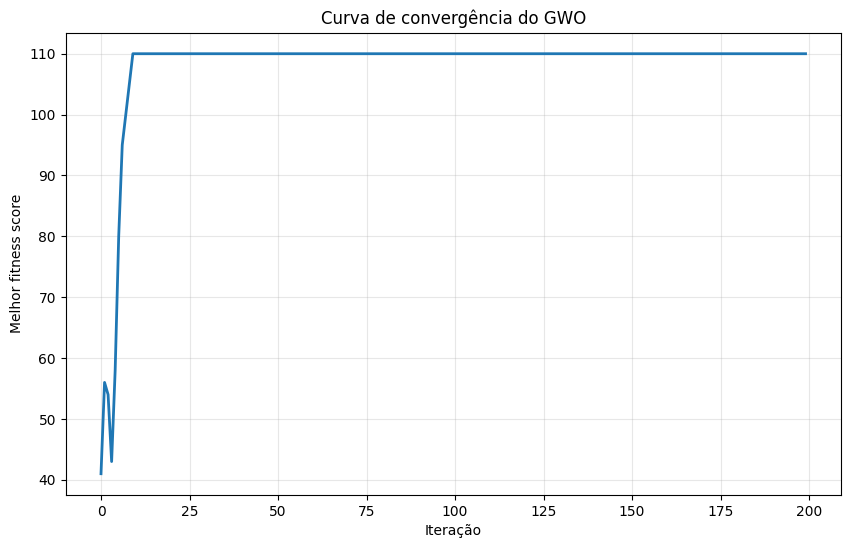


Análise de Convergência:
Fitness inicial: 41.00
Fitness final: 110.00
Melhoria: 69.00
Melhor score encontrado: 110.00


In [4]:
import matplotlib.pyplot as plt


plt.figure(figsize=(10, 6))
plt.plot(convergence, linewidth=2)
plt.xlabel("Iteração")
plt.ylabel("Melhor fitness score")
plt.title("Curva de convergência do GWO")
plt.grid(True, alpha=0.3)
plt.show()

print(f"\nAnálise de Convergência:")
print(f"Fitness inicial: {convergence[0]:.2f}")
print(f"Fitness final: {convergence[-1]:.2f}")
print(f"Melhoria: {convergence[-1] - convergence[0]:.2f}")
print(f"Melhor score encontrado: {best_fitness:.2f}")